# Introduction
There has been recent discourse over the increased use of generative AI amongst students. Due to this rising trend I think it's important to understand its possible implications as it pertains to scholastic performance, and its use. To help me gain some insight into this increase in popularity of generative AI I'll be analyzing a dataset collected from students at the collegiate level.  
## Goal
My goal for this project is to identify driving factors for the adoption of generative AI amongst students and its effect on academic performance.
### Questions
1. What is the most common use for generative AI?
2. Is there a relationship between academic performance and generative AI use?
3. Is there a stronger correlation between academic performance and generative AI use than academic performance and traditional studying?

In [1]:
#import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#set settings for dataframe display
pd.set_option('display.expand_frame_repr', False)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)


#  Intital Data Inspection observations

During my data exploration a few of the variables drew my attention: Weekly_GenAI_Hours, Traditional_Study_Hours, Pre_Semester_GPA, Post_Semester_GPA. I plan to begin my analysis by focusing
on these to start.

Aside from some small changes I made, the data was mostly clean. The data type assigned to each column aligned with the values entered, and no no null values presented themselves in my initially. I did notice the GPAs were being reported with three decimal places so I rounded them down to two decimals for readability and to more align with common gpa reporting practices.

In [3]:
#load data
data = pd.read_csv('ai_student_impact_dataset_original.csv')

data.head(10)

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,100001,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44,High
1,100002,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low
2,100003,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,3.499,73.93,Medium
3,100004,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,4.000,63.58,Medium
4,100005,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4,3.798,100.00,Medium
5,100006,STEM,Junior,3.449,6.50,Debugging/Troubleshooting,Beginner,1,False,14.19,4,Allowed_With_Citation,5,3.666,65.92,High
6,100007,STEM,Freshman,3.622,31.41,Summarizing_Reading,Advanced,5,True,13.11,8,Allowed_With_Citation,7,4.000,67.97,Medium
7,100008,Arts,Junior,2.746,5.33,Copywriting/Drafting,Intermediate,3,False,18.45,2,Actively_Encouraged,1,2.965,85.09,Medium
8,100009,Business,Sophomore,3.420,2.00,Debugging/Troubleshooting,Beginner,2,True,2.87,1,Strict_Ban,5,3.396,55.71,Medium
9,100010,Business,Sophomore,3.046,19.99,Debugging/Troubleshooting,Intermediate,2,True,12.49,3,Strict_Ban,8,2.978,87.18,High


In [4]:
#data information
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  50000 non-null  int64  
 1   Major_Category              50000 non-null  str    
 2   Year_of_Study               50000 non-null  str    
 3   Pre_Semester_GPA            50000 non-null  float64
 4   Weekly_GenAI_Hours          50000 non-null  float64
 5   Primary_Use_Case            50000 non-null  str    
 6   Prompt_Engineering_Skill    50000 non-null  str    
 7   Tool_Diversity              50000 non-null  int64  
 8   Paid_Subscription           50000 non-null  bool   
 9   Traditional_Study_Hours     50000 non-null  float64
 10  Perceived_AI_Dependency     50000 non-null  int64  
 11  Institutional_Policy        50000 non-null  str    
 12  Anxiety_Level_During_Exams  50000 non-null  int64  
 13  Post_Semester_GPA           50000 non-null

In [5]:
#data description except for the Student_ID column
data.drop(columns=['Student_ID']).describe(include = 'all')

,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
count,50000,50000,50000.000000,50000.000000,50000,50000,50000.00000,50000,50000.000000,50000.000000,50000,50000.000000,50000.000000,50000.000000,50000
unique,5,5,NaN,NaN,5,3,NaN,2,NaN,NaN,3,NaN,NaN,NaN,3
top,STEM,Junior,NaN,NaN,Debugging/Troubleshooting,Beginner,NaN,False,NaN,NaN,Allowed_With_Citation,NaN,NaN,NaN,Medium
freq,15059,11045,NaN,NaN,12295,18495,NaN,28846,NaN,NaN,25224,NaN,NaN,NaN,21144
mean,NaN,NaN,3.146102,8.427752,NaN,NaN,2.80026,NaN,11.209271,3.505360,NaN,4.270760,3.349299,75.798125,NaN
std,NaN,NaN,0.478854,8.269490,NaN,NaN,1.18802,NaN,5.156426,1.820812,NaN,2.144066,0.495673,13.281626,NaN
min,NaN,NaN,1.183000,0.000000,NaN,NaN,1.00000,NaN,1.000000,1.000000,NaN,1.000000,1.000000,10.780000,NaN
25%,NaN,NaN,2.834000,2.390000,NaN,NaN,2.00000,NaN,7.560000,2.000000,NaN,3.000000,3.023750,66.820000,NaN
50%,NaN,NaN,3.210000,5.800000,NaN,NaN,3.00000,NaN,11.180000,3.000000,NaN,4.000000,3.421000,76.000000,NaN
75%,NaN,NaN,3.521000,11.720000,NaN,NaN,4.00000,NaN,14.710000,5.000000,NaN,6.000000,3.749000,85.190000,NaN


In [6]:
#view columns
dataset_columns = data.columns

print(dataset_columns)

Index(['Student_ID', 'Major_Category', 'Year_of_Study', 'Pre_Semester_GPA', 'Weekly_GenAI_Hours', 'Primary_Use_Case', 'Prompt_Engineering_Skill', 'Tool_Diversity', 'Paid_Subscription', 'Traditional_Study_Hours', 'Perceived_AI_Dependency', 'Institutional_Policy', 'Anxiety_Level_During_Exams', 'Post_Semester_GPA', 'Skill_Retention_Score', 'Burnout_Risk_Level'], dtype='str')


In [7]:
#check for exact duplicates
exact_dups = data.duplicated().sum()
print(f"Number of exact duplicate rows: {exact_dups}")

#check for parital duplicates based on Student ID 
partial_dups = data.duplicated(subset = ['Student_ID']).sum()
print(f"Number of partial duplicate rows based on Student ID: {partial_dups}")


Number of exact duplicate rows: 0
Number of partial duplicate rows based on Student ID: 0


In [8]:
#round the GPA columns to two decimal places
data[['Pre_Semester_GPA', 'Post_Semester_GPA']] = round(data[['Pre_Semester_GPA', 'Post_Semester_GPA']], 2)

data[['Pre_Semester_GPA', 'Post_Semester_GPA']].head()

,Pre_Semester_GPA,Post_Semester_GPA
0,2.42,2.39
1,3.82,3.70
2,3.40,3.50
3,3.79,4.00
4,3.64,3.80


# Data Cleaning

- Reformatted/Renamed the values in primary use case column
- Created derivative columns from weekly gen ai usage and traditional study and binned them into three groups of low, moderate, high respectively.
- Converted GPAs into their letter grade equivalent and created a column for them
- Created a column that recorded the change in gpa by subtracting post and pre gpa
- reorganized the columns to put related columns closer together for better comparison
- added a rank order to categorical variables.

In [9]:
#check the unique values in each column excluding 'Student_ID' and continuous variables
for column in dataset_columns.drop('Student_ID'):
    data_col = data[column]
    if data_col.dtypes != 'float':
        if data_col.dtypes == 'str':
            print(f'Unique values in {column}: {list(data_col.unique())}', '\n')
        else:
            print(f'Unique values in {column}: {data_col.unique()}', '\n')

Unique values in Major_Category: ['Humanities', 'Medical', 'Business', 'STEM', 'Arts'] 

Unique values in Year_of_Study: ['Senior', 'Junior', 'Freshman', 'Sophomore', 'Graduate'] 

Unique values in Primary_Use_Case: ['Copywriting/Drafting', 'Ideation', 'Summarizing_Reading', 'Debugging/Troubleshooting', 'Direct_Answer_Generation'] 

Unique values in Prompt_Engineering_Skill: ['Beginner', 'Advanced', 'Intermediate'] 

Unique values in Tool_Diversity: [1 5 2 4 3] 

Unique values in Paid_Subscription: [ True False] 

Unique values in Perceived_AI_Dependency: [ 5  3  2  4  8  1  6  7 10  9] 

Unique values in Institutional_Policy: ['Allowed_With_Citation', 'Strict_Ban', 'Actively_Encouraged'] 

Unique values in Anxiety_Level_During_Exams: [ 6  9  2  4  5  7  1  8  3 10] 

Unique values in Burnout_Risk_Level: ['High', 'Low', 'Medium'] 



In [10]:
#replace 'Medium' with 'Moderate' in the Burnout_Risk_Level column
data['Burnout_Risk_Level'] = data['Burnout_Risk_Level'].replace({'Medium': 'Moderate'})

data['Burnout_Risk_Level'].head()

0        High
1         Low
2    Moderate
3    Moderate
4    Moderate
Name: Burnout_Risk_Level, dtype: str

In [11]:
data['Primary_Use_Case'] = data['Primary_Use_Case'].replace({'Copywriting/Drafting' : 'Drafting', 'Summarizing_Reading' : 'Summarizing', 
                                                             'Debugging/Troubleshooting' : 'Troubleshooting', 'Direct_Answer_Generation' : 'Answer_Generation'})

print(f'Primary_Use_Case reformatted values: {list(data["Primary_Use_Case"].unique())}')

Primary_Use_Case reformatted values: ['Drafting', 'Ideation', 'Summarizing', 'Troubleshooting', 'Answer_Generation']


In [12]:
#create a function for converting GPAs to letter grades

def assign_letter_grade(gpa):
    if gpa >= 3.7:
        return 'A'
    elif gpa >= 2.7:
        return 'B'
    elif gpa >= 1.7:
        return 'C'
    elif gpa >= 0.7:
        return 'D'
    else:
        return 'F'
    
#create new column with letter grades
data['Pre_Sem_Letter_Grade'] = data['Pre_Semester_GPA'].apply(assign_letter_grade)

data['Post_Sem_Letter_Grade'] = data['Post_Semester_GPA'].apply(assign_letter_grade)

data[['Pre_Semester_GPA', 'Pre_Sem_Letter_Grade', 'Post_Semester_GPA','Post_Sem_Letter_Grade']].head(10)

,Pre_Semester_GPA,Pre_Sem_Letter_Grade,Post_Semester_GPA,Post_Sem_Letter_Grade
0,2.42,C,2.39,C
1,3.82,A,3.70,A
2,3.40,B,3.50,B
3,3.79,A,4.00,A
4,3.64,B,3.80,A
5,3.45,B,3.67,B
6,3.62,B,4.00,A
7,2.75,B,2.96,B
8,3.42,B,3.40,B
9,3.05,B,2.98,B


In [13]:
#create a bracket for time spent using AI tools or traditional study methods
def assign_time_bracket(time_spent):
    if time_spent >= 25:
        return 'High'
    elif time_spent >= 15:
        return 'Moderate'
    else:
        return 'Low'

data['AI_Usage_Cat'] = data['Weekly_GenAI_Hours'].apply(assign_time_bracket)

data['Study_Time_Cat'] = data['Traditional_Study_Hours'].apply(assign_time_bracket)

data[['Weekly_GenAI_Hours','AI_Usage_Cat', 'Traditional_Study_Hours', 'Study_Time_Cat']].head(10)

,Weekly_GenAI_Hours,AI_Usage_Cat,Traditional_Study_Hours,Study_Time_Cat
0,23.31,Moderate,8.13,Low
1,1.12,Low,16.65,Moderate
2,21.26,Moderate,10.35,Low
3,1.82,Low,15.23,Moderate
4,9.29,Low,12.55,Low
5,6.50,Low,14.19,Low
6,31.41,High,13.11,Low
7,5.33,Low,18.45,Moderate
8,2.00,Low,2.87,Low
9,19.99,Moderate,12.49,Low


In [14]:
#calculate the change in GPA
data['GPA_Change'] = data['Post_Semester_GPA'] - data['Pre_Semester_GPA']

data[[ 'Pre_Semester_GPA','GPA_Change', 'Post_Semester_GPA']].head()

,Pre_Semester_GPA,GPA_Change,Post_Semester_GPA
0,2.42,-0.03,2.39
1,3.82,-0.12,3.70
2,3.40,0.10,3.50
3,3.79,0.21,4.00
4,3.64,0.16,3.80


In [15]:
#view the columns after creating the new columns
data.columns

Index(['Student_ID', 'Major_Category', 'Year_of_Study', 'Pre_Semester_GPA', 'Weekly_GenAI_Hours', 'Primary_Use_Case', 'Prompt_Engineering_Skill', 'Tool_Diversity', 'Paid_Subscription', 'Traditional_Study_Hours', 'Perceived_AI_Dependency', 'Institutional_Policy', 'Anxiety_Level_During_Exams', 'Post_Semester_GPA', 'Skill_Retention_Score', 'Burnout_Risk_Level', 'Pre_Sem_Letter_Grade', 'Post_Sem_Letter_Grade', 'AI_Usage_Cat', 'Study_Time_Cat', 'GPA_Change'], dtype='str')

In [16]:
#reorder columns
data = data[['Student_ID', 'Major_Category', 'Year_of_Study', 'Pre_Semester_GPA',
       'Pre_Sem_Letter_Grade', 'Post_Semester_GPA', 'Post_Sem_Letter_Grade', 'GPA_Change',
       'Primary_Use_Case', 'Weekly_GenAI_Hours', 'AI_Usage_Cat', 'Traditional_Study_Hours',
       'Study_Time_Cat','Prompt_Engineering_Skill', 'Tool_Diversity', 'Paid_Subscription',
       'Perceived_AI_Dependency', 'Institutional_Policy', 'Anxiety_Level_During_Exams',
       'Skill_Retention_Score', 'Burnout_Risk_Level']]

data.head()

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Pre_Sem_Letter_Grade,Post_Semester_GPA,Post_Sem_Letter_Grade,GPA_Change,Primary_Use_Case,Weekly_GenAI_Hours,AI_Usage_Cat,Traditional_Study_Hours,Study_Time_Cat,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Skill_Retention_Score,Burnout_Risk_Level
0,100001,Humanities,Senior,2.42,C,2.39,C,-0.03,Drafting,23.31,Moderate,8.13,Low,Beginner,1,True,5,Allowed_With_Citation,6,86.44,High
1,100002,Medical,Junior,3.82,A,3.70,A,-0.12,Ideation,1.12,Low,16.65,Moderate,Advanced,5,False,3,Allowed_With_Citation,9,69.39,Low
2,100003,Business,Freshman,3.40,B,3.50,B,0.10,Summarizing,21.26,Moderate,10.35,Low,Beginner,2,False,5,Strict_Ban,9,73.93,Moderate
3,100004,Business,Senior,3.79,A,4.00,A,0.21,Drafting,1.82,Low,15.23,Moderate,Intermediate,4,False,2,Allowed_With_Citation,2,63.58,Moderate
4,100005,STEM,Sophomore,3.64,B,3.80,A,0.16,Troubleshooting,9.29,Low,12.55,Low,Advanced,4,False,4,Allowed_With_Citation,4,100.00,Moderate


In [17]:
#order the categorical values
data['Year_of_Study'] = pd.Categorical(data['Year_of_Study'], categories=['Freshman', 'Sophomore', 'Junior', 'Senior', 'Graduate'], ordered=True)
print(data.Year_of_Study.unique(), '\n')

data['Pre_Sem_Letter_Grade'] = pd.Categorical(data['Pre_Sem_Letter_Grade'],
                                                                         categories=['F', 'D', 'C', 'B', 'A'], ordered=True)
print(data.Pre_Sem_Letter_Grade.unique(), '\n')

data['Post_Sem_Letter_Grade'] = pd.Categorical(data['Post_Sem_Letter_Grade'],
                                                                          categories=['F','D', 'C', 'B', 'A'], ordered=True)
print(data.Post_Sem_Letter_Grade.unique(), '\n') 

data['AI_Usage_Cat'] = pd.Categorical(data['AI_Usage_Cat'], categories=['Low', 'Moderate', 'High'], ordered=True)
print(data.AI_Usage_Cat.unique(), '\n')

data['Study_Time_Cat'] = pd.Categorical(data['Study_Time_Cat'], categories=['Low', 'Moderate', 'High'], ordered=True)
print(data.Study_Time_Cat.unique(), '\n')

data['Prompt_Engineering_Skill'] = pd.Categorical(data['Prompt_Engineering_Skill'], categories=['Beginner', 'Intermediate', 'Advanced'], ordered=True)
print(data.Prompt_Engineering_Skill.unique(), '\n')

data['Institutional_Policy'] = pd.Categorical(data['Institutional_Policy'], categories=['Strict_Ban', 'Allowed_With_Citation', 'Actively_Encouraged'], ordered=True)
print(data.Institutional_Policy.unique(), '\n')

data['Burnout_Risk_Level'] = pd.Categorical(data['Burnout_Risk_Level'], categories=['Low', 'Moderate', 'High'], ordered=True)
print(data.Burnout_Risk_Level.unique(), '\n')

['Senior', 'Junior', 'Freshman', 'Sophomore', 'Graduate']
Categories (5, str): ['Freshman' < 'Sophomore' < 'Junior' < 'Senior' < 'Graduate'] 

['C', 'A', 'B', 'D']
Categories (5, str): ['F' < 'D' < 'C' < 'B' < 'A'] 



['C', 'A', 'B', 'D']
Categories (5, str): ['F' < 'D' < 'C' < 'B' < 'A'] 

['Moderate', 'Low', 'High']
Categories (3, str): ['Low' < 'Moderate' < 'High'] 

['Low', 'Moderate', 'High']
Categories (3, str): ['Low' < 'Moderate' < 'High'] 

['Beginner', 'Advanced', 'Intermediate']
Categories (3, str): ['Beginner' < 'Intermediate' < 'Advanced'] 

['Allowed_With_Citation', 'Strict_Ban', 'Actively_Encouraged']
Categories (3, str): ['Strict_Ban' < 'Allowed_With_Citation' < 'Actively_Encouraged'] 

['High', 'Low', 'Moderate']
Categories (3, str): ['Low' < 'Moderate' < 'High'] 



## Exploratory Analysis

- Most of histogram plots show fairly normal shapes with only slight tails.
- Weekly GenAI shows a heavily skewed plot with a long tail to the right.
    - also has a mean and median with the biggest difference.
- Histogram of GPA change has the most normal shape with data.

- Troubleshooting is the most common use for gen AI, followed closely by drafting, and then ideation.
- Majority of students are B students.
- Most students also fall into the low group for ai usage and study time.
- Only about 20% of institutions ban the use of AI.

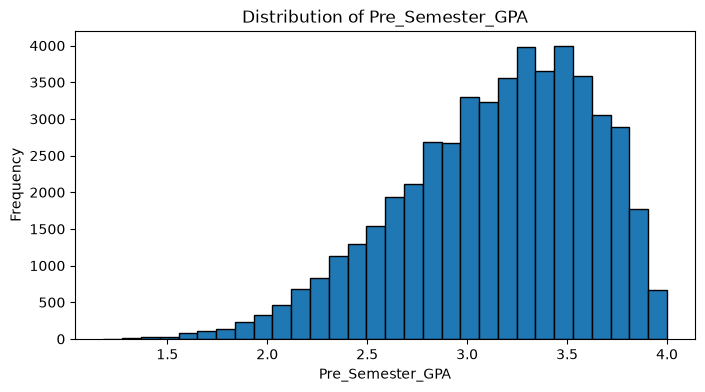

Pre_Semester_GPA Average: 3.15 
 Pre_Semester_GPA Median: 3.21 



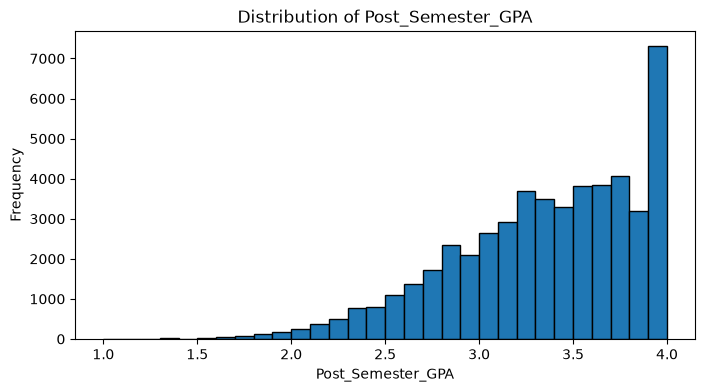

Post_Semester_GPA Average: 3.35 
 Post_Semester_GPA Median: 3.42 



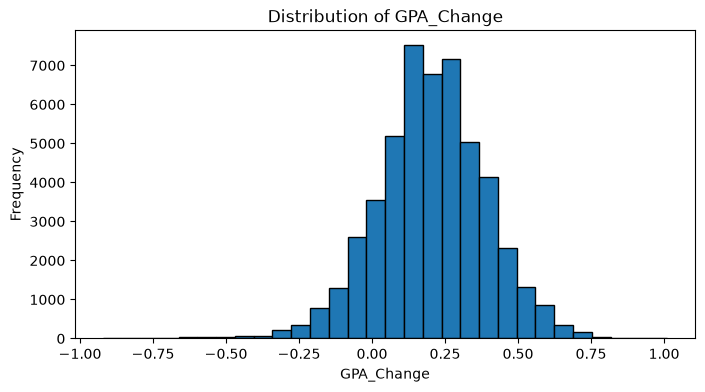

GPA_Change Average: 0.2 
 GPA_Change Median: 0.2 



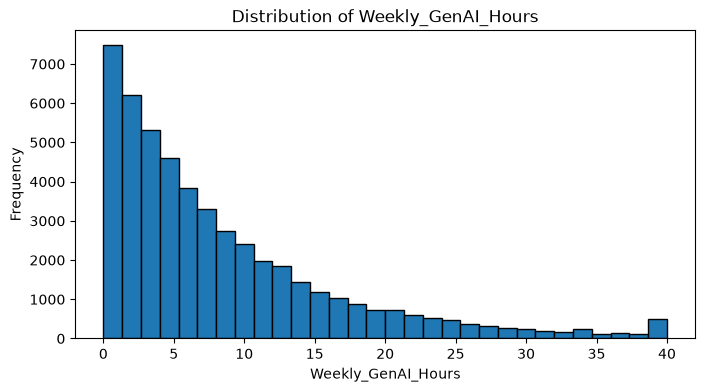

Weekly_GenAI_Hours Average: 8.43 
 Weekly_GenAI_Hours Median: 5.8 



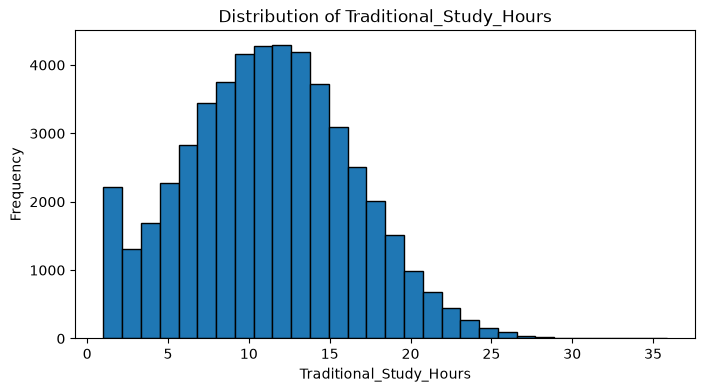

Traditional_Study_Hours Average: 11.21 
 Traditional_Study_Hours Median: 11.18 



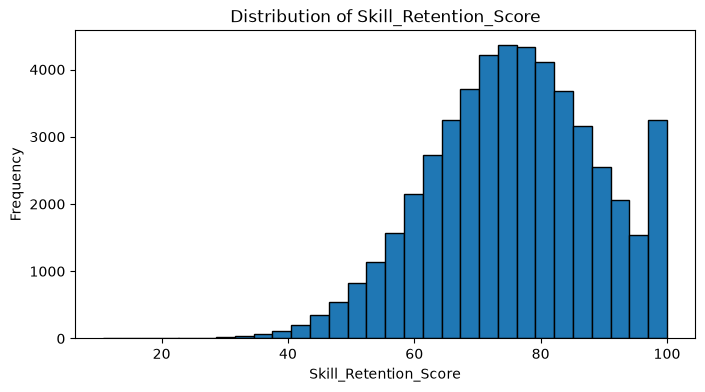

Skill_Retention_Score Average: 75.8 
 Skill_Retention_Score Median: 76.0 



In [18]:
#plot histograms for the continuous variables

for column in data.drop(columns = ['Student_ID']).select_dtypes(include=[float]).columns:
    plt.figure(figsize=(8, 4))
    plt.hist(data[column], bins=30, edgecolor='black')
    plt.title(f'Distribution of {column}')
    plt.xlabel(column)
    plt.ylabel('Frequency')
    plt.show()
    print(f"{column} Average: {round(data[column].mean(), 2)}", '\n',f"{column} Median: {round(data[column].median(), 2)}", '\n')

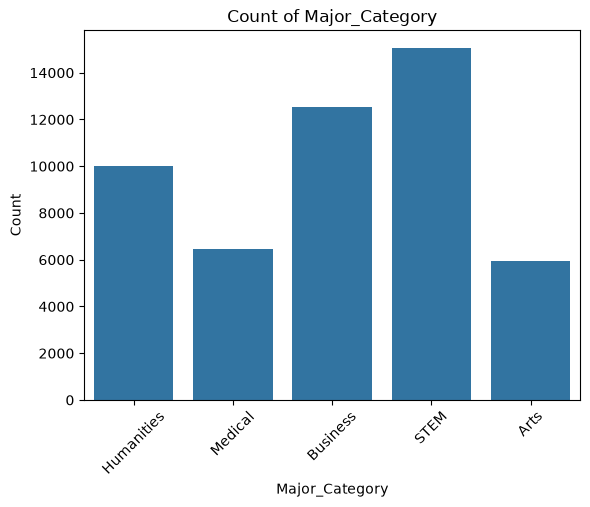

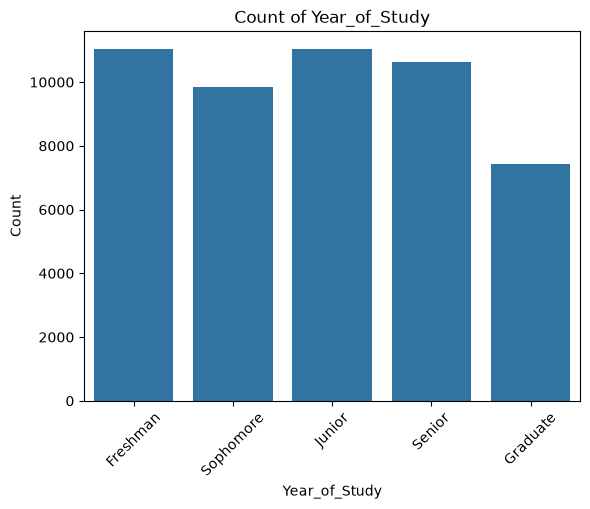

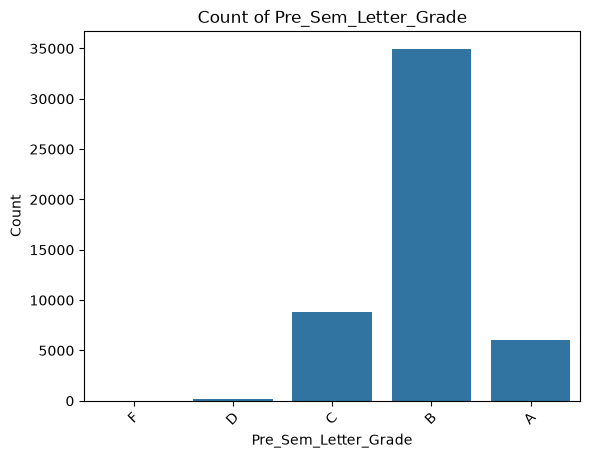

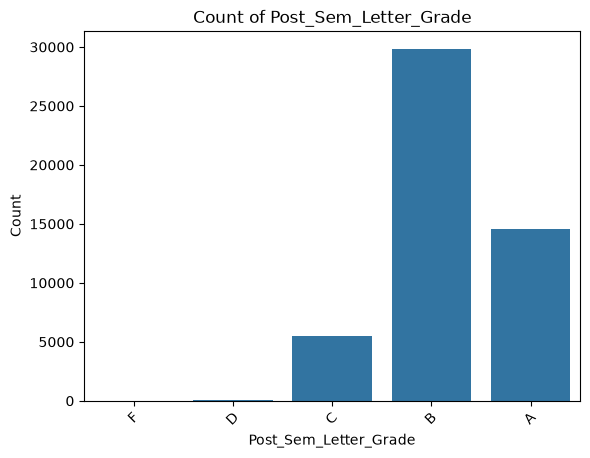

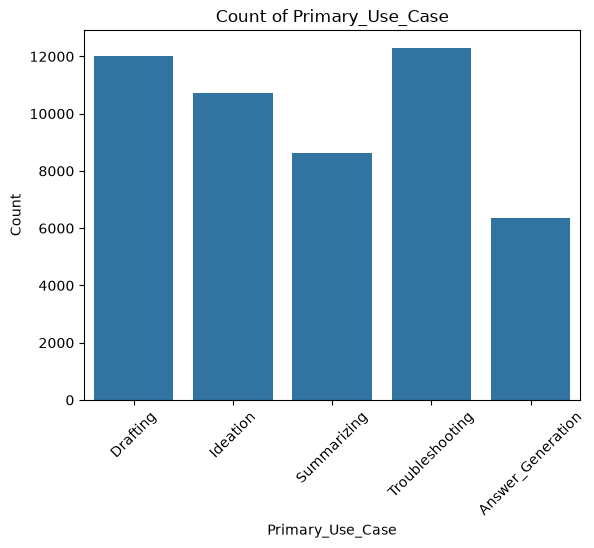

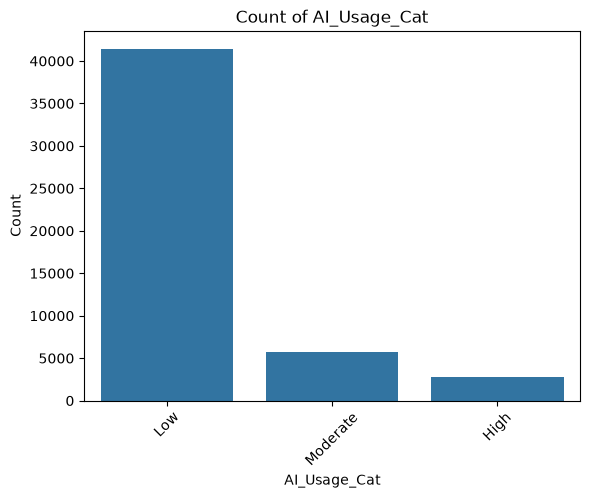

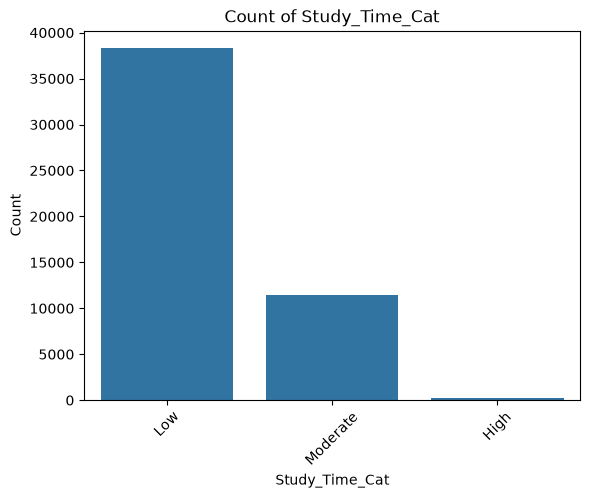

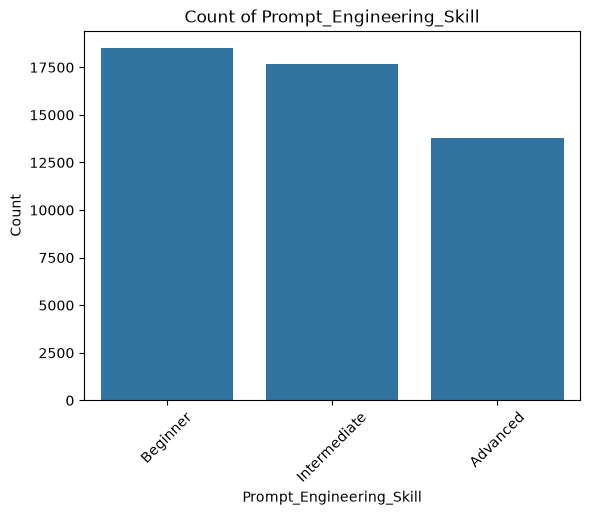

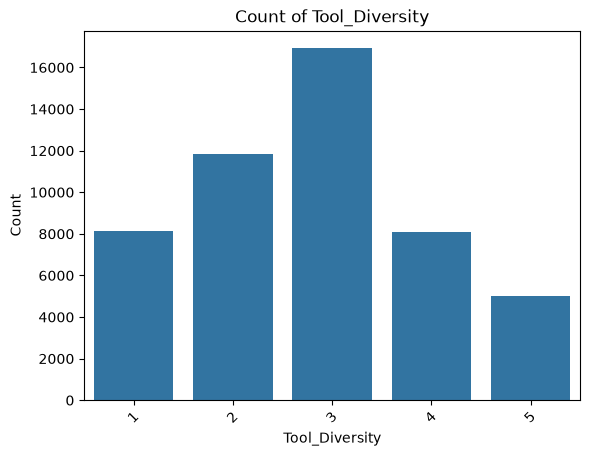

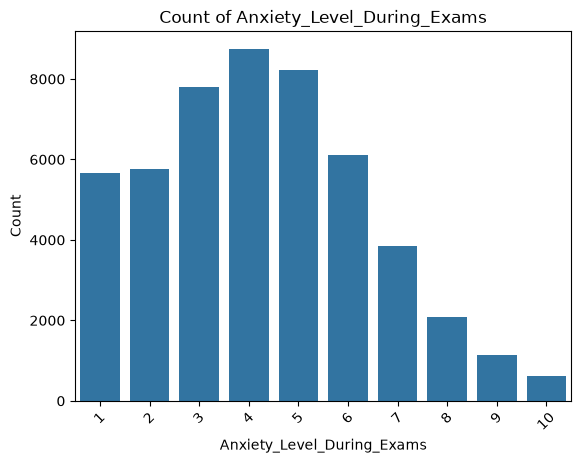

In [19]:
countplot_cols = ['Major_Category', 'Year_of_Study', 'Pre_Sem_Letter_Grade', 'Post_Sem_Letter_Grade', 'Primary_Use_Case', 
             'AI_Usage_Cat', 'Study_Time_Cat', 'Prompt_Engineering_Skill', 'Tool_Diversity', 'Anxiety_Level_During_Exams']

for col in countplot_cols:
    sns.countplot(data=data, x=col)
    plt.title(f'Count of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.show()


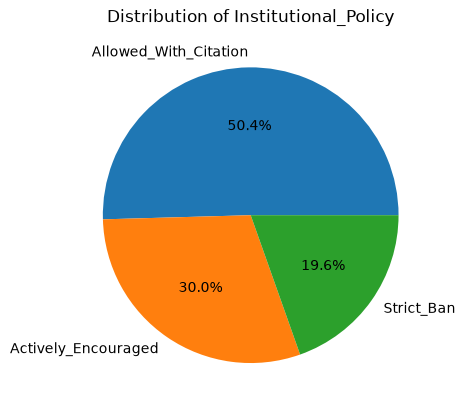

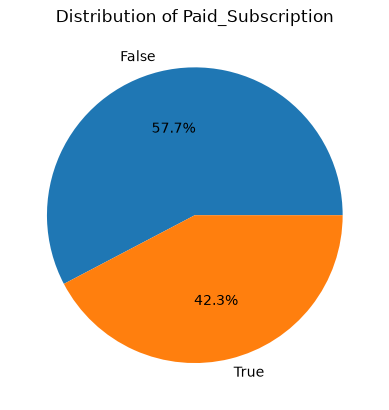

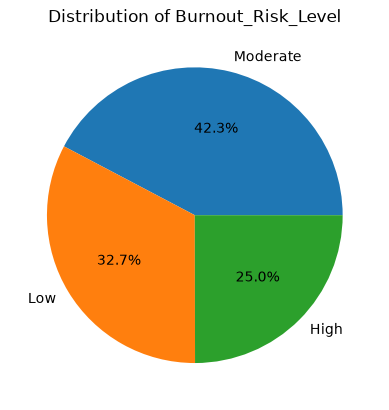

In [20]:
pie_chart_cols = ['Institutional_Policy', 'Paid_Subscription', 'Burnout_Risk_Level']

for col in pie_chart_cols:
    plt.pie(data[col].value_counts(), labels=data[col].value_counts().index, autopct='%1.1f%%')
    plt.title(f'Distribution of {col}')
    plt.ylabel('')
    plt.show()  

## Bivariate Analysis
- Post and Pre semester GPA have the strongest correlation.
- Students that spend more time using gen AI tend to have higher percieved gen AI dependency.
-  Weekly gen AI hours has almost no, or near no correlation with either pre, or post GPA column.
    - also no correlation with gpa change column
-   Moderate positive correlation between traditional study hours and GPA change.

- Students in the high gen AI usage category also tend to report proportianately higher for high burnout risk.
- Students report proportiantely more in the low-moderate burnout risk levels for high traditonal study hours.

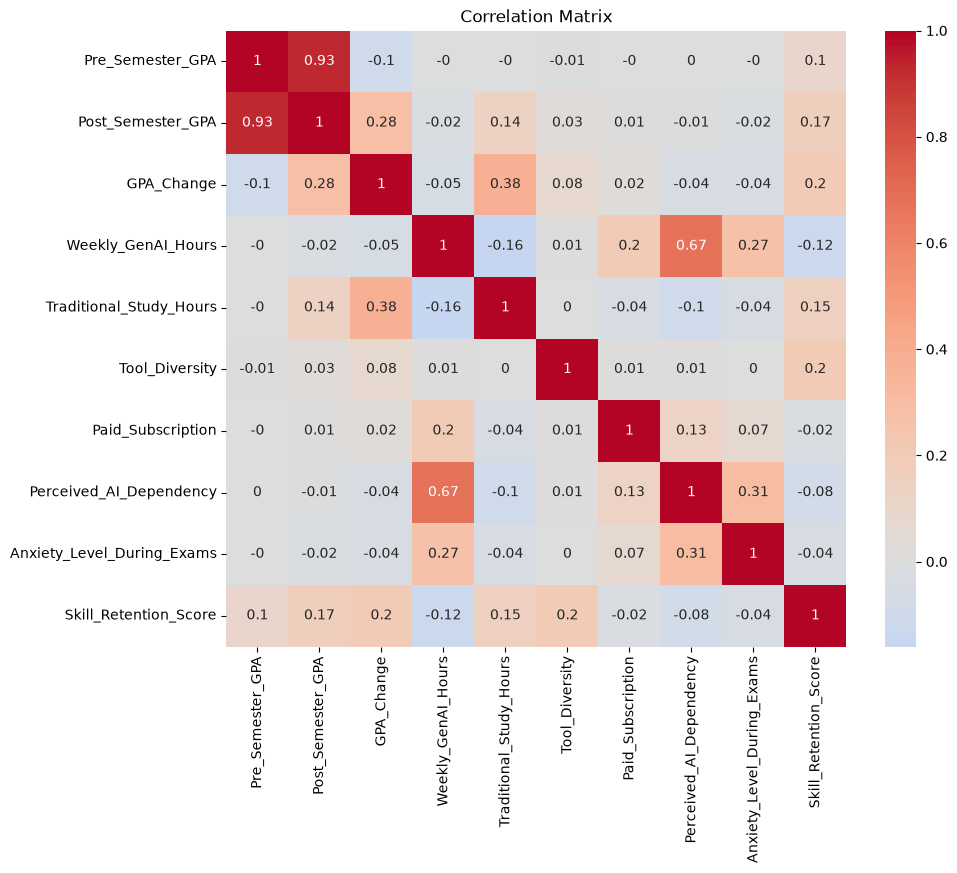

In [21]:
#create correlation matrix
num_corr = data.drop(['Student_ID'], axis=1).corr(numeric_only=True, method='pearson').round(2)

plt.figure(figsize=(10, 8)) 
sns.heatmap(num_corr, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.show()

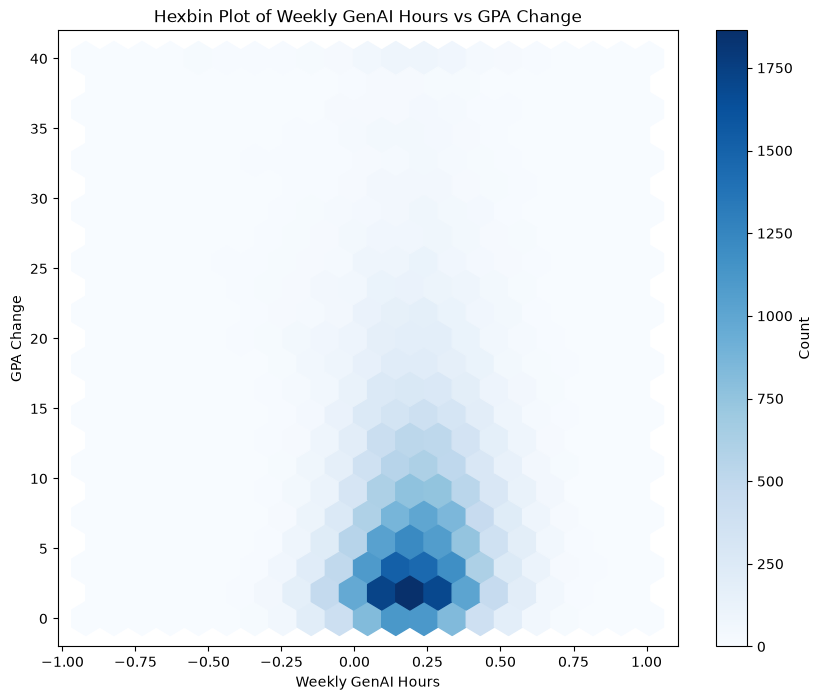

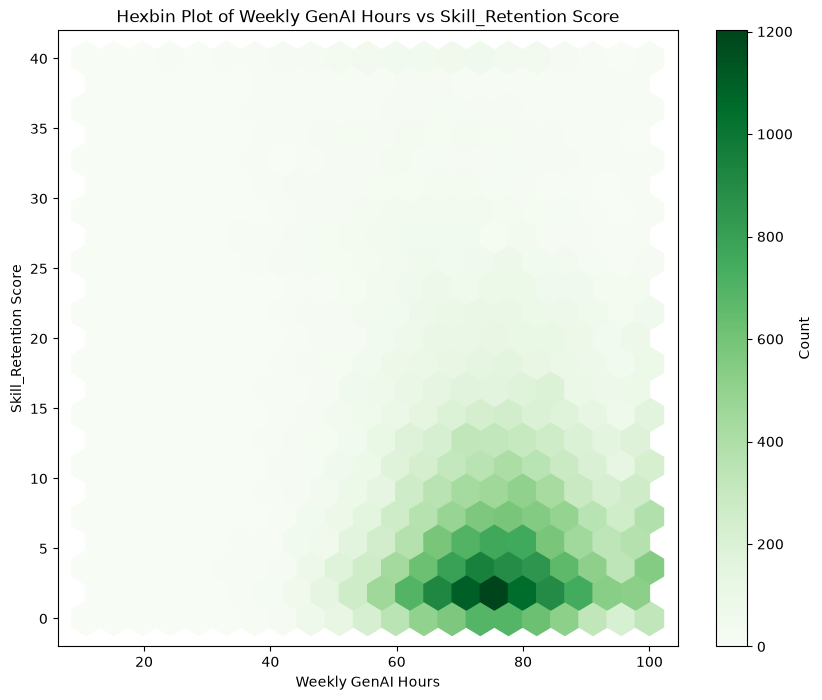

In [22]:
#plot a hexbin plot comparing Weekly GenAI Hours and GPA Change
plt.figure(figsize=(10, 8))
plt.hexbin(data['GPA_Change'], data['Weekly_GenAI_Hours'], gridsize=20, cmap='Blues')
plt.xlabel('Weekly GenAI Hours')
plt.ylabel('GPA Change')
plt.title('Hexbin Plot of Weekly GenAI Hours vs GPA Change')
plt.colorbar(label='Count')
plt.show()

#plot a hexbin plot comparing Weekly GenAI Hours and retention score
plt.figure(figsize=(10, 8))
plt.hexbin(data['Skill_Retention_Score'], data['Weekly_GenAI_Hours'], gridsize=20, cmap='Greens')
plt.xlabel('Weekly GenAI Hours')
plt.ylabel('Skill_Retention Score')
plt.title('Hexbin Plot of Weekly GenAI Hours vs Skill_Retention Score')
plt.colorbar(label='Count')
plt.show()

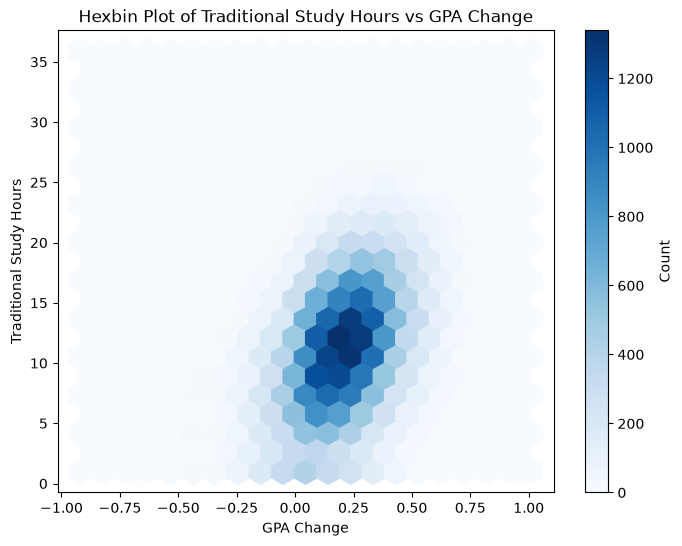

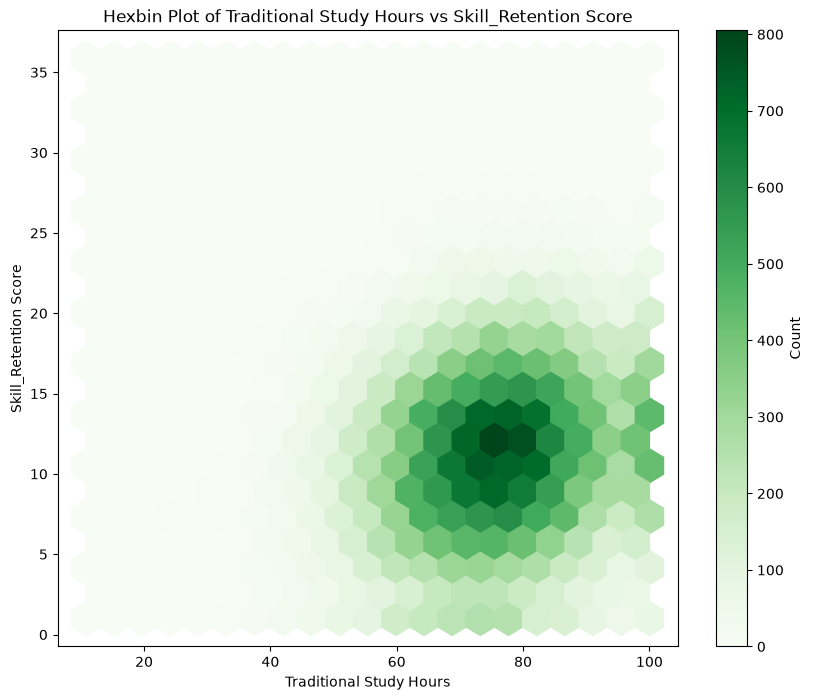

In [23]:
plt.figure(figsize=(8, 6))
plt.hexbin(data['GPA_Change'], data['Traditional_Study_Hours'], gridsize=20, cmap='Blues')
plt.xlabel('GPA Change')
plt.ylabel('Traditional Study Hours')   
plt.title('Hexbin Plot of Traditional Study Hours vs GPA Change')
plt.colorbar(label='Count')
plt.show()

#plot a hexbin plot comparing Weekly Traditional Study Hours and retention score
plt.figure(figsize=(10, 8))
plt.hexbin(data['Skill_Retention_Score'], data['Traditional_Study_Hours'], gridsize=20, cmap='Greens')
plt.xlabel('Traditional Study Hours')
plt.ylabel('Skill_Retention Score')
plt.title('Hexbin Plot of Traditional Study Hours vs Skill_Retention Score')
plt.colorbar(label='Count')
plt.show()

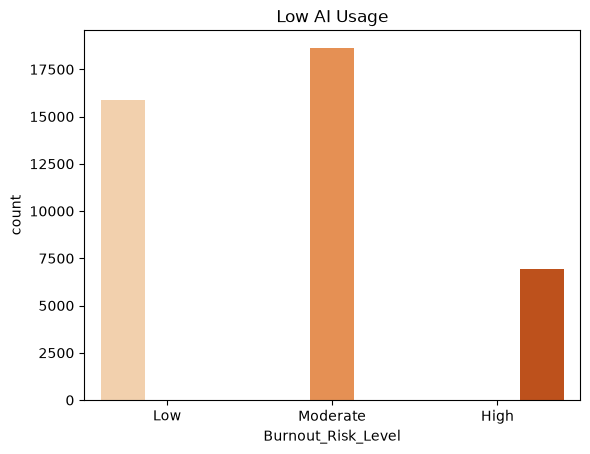

Data size: 41458 



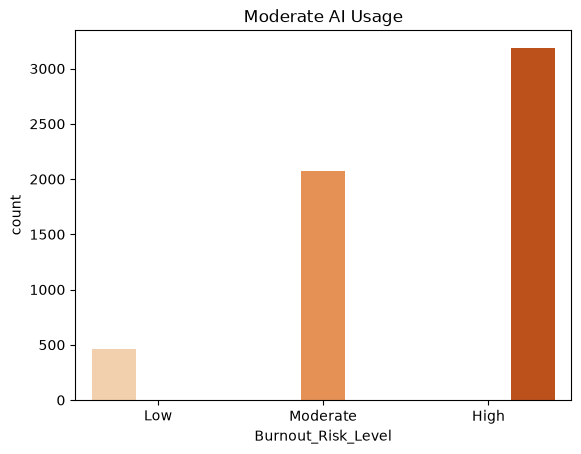

Data size: 5720 



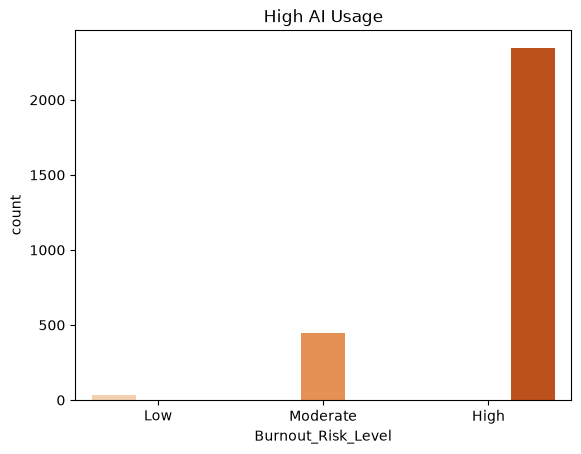

Data size: 2822 

Burnout_Risk_Level    Low  Moderate   High
AI_Usage_Cat                              
Low                 38.30     44.92  16.78
Moderate             8.04     36.26  55.70
High                 1.13     15.77  83.10
All                 32.74     42.29  24.97


In [30]:
#look at the distribution of burnout risk levels across different AI usage categories
for val in data['AI_Usage_Cat'].cat.categories.unique():
    subset=data[data['AI_Usage_Cat'] == val]

    sns.countplot(data=subset , x='Burnout_Risk_Level', hue='Burnout_Risk_Level',palette='Oranges')
    plt.title(f'{val} AI Usage')
    plt.show()
    print(f'Data size: {len(subset)}', '\n')
#create a crosstab table for AI usage and burnout risk levels to show as percentages
ai_burnout_crostab = round(pd.crosstab(data['AI_Usage_Cat'], data['Burnout_Risk_Level'], margins=True, normalize='index') * 100, 2)

print(ai_burnout_crostab)

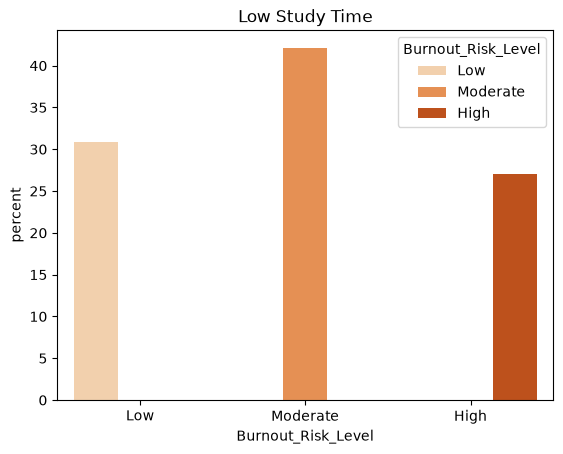

Data size: 38310 



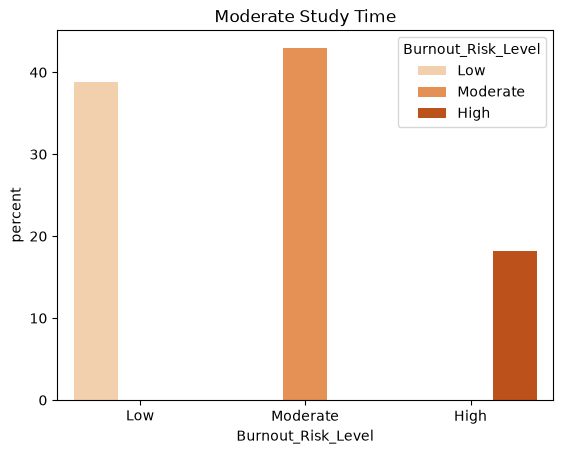

Data size: 11475 



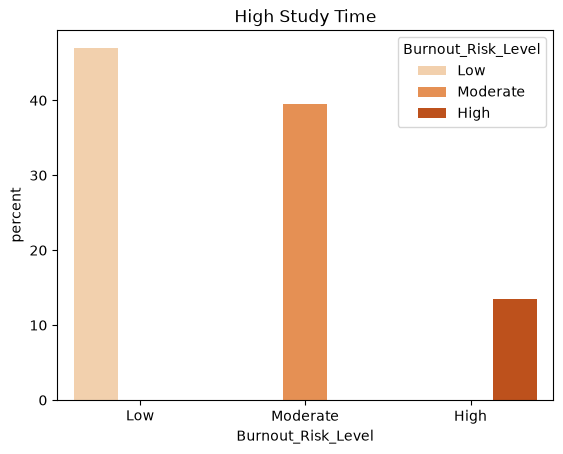

Data size: 215 

Burnout_Risk_Level    Low  Moderate   High
Study_Time_Cat                            
Low                 30.83     42.10  27.07
Moderate            38.84     42.95  18.20
High                46.98     39.53  13.49
All                 32.74     42.29  24.97


In [29]:
for val in data['Study_Time_Cat'].cat.categories.unique():
    subset=data[data['Study_Time_Cat'] == val]

    sns.countplot(data=subset , x='Burnout_Risk_Level', hue='Burnout_Risk_Level', stat= 'percent',palette='Oranges', legend = 'brief',)
    plt.title(f'{val} Study Time')
    plt.show()
    print(f'Data size: {len(subset)}', '\n')

study_burnout_crosstab = round(pd.crosstab(data['Study_Time_Cat'], data['Burnout_Risk_Level'], margins=True, normalize='index') * 100, 2)
print(study_burnout_crosstab)

## Conclusion

Through my analysis, the average weekly time a student spends on generative AI showed to have no linear relationship with academic performance. In contrast, traditional studying did show a positive moderate correlation with the GPA change column, which contained the increase or decrease in GPA a student saw during the semester. This shows that time spent with traditional studying is more meaningfully related to a student's academic performance in comparison to weekly generative AI use.

While generative AI use did not correlate with GPA change, there did seem to be a relationship with reported burnout risk level. As I moved from the low use group to the high use group the proportion of students reporting high burnout risk also increased while the plots of reported burnout risk by study time category showed the opposite trend. The proportion of students reporting high burnout risk decreased while the proportion of low and moderate burnout risk increased as you go from low study time to high study time.
 
In conclusion while the use of generative AI did not correlate strongly with academic outcomes, the relationship shown in the countplots of burnout risk by AI usage group suggest they might be choosing to use generative AI as a last resort tool due to stress or burnout risk. This is still speculative and would need to be looked into further. 
